# 1. Matrice di Correlazione e PCA
Analisi delle relazioni statistiche tra 8 inquinanti (NOx, NO2, SO2, CO, O3, PM10, PM2.5, Benzene) attraverso una matrice di correlazione e un'analisi delle componenti principali (PCA).

In [1]:
import geopandas as gpd
import h3pandas
from shapely.geometry import Point, Polygon
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Importazione e pulizia dati

In [4]:
#importazione dati
dati = pd.read_csv("/Users/giulia/Documents/geopandas/Air-quality-Lombardy-2025/data/Dati_sensori_aria_2025.csv")
stazioni = gpd.read_file("/Users/giulia/Documents/geopandas/Air-quality-Lombardy-2025/data/Stazioni qualità dell aria_20260826/geo_export_1e1f2c5a-263d-4a72-908d-7477842f54c0.shp")

In [5]:
#pulizia dei dati di qualità dell'aria e delle stazioni
import functions as f
dati_puliti = f.pulizia_dati(dati)
stazioni_pulite = f.pulizia_stazioni(stazioni)

# Merge stazioni e dati

In [20]:
#merge stazioni e dati 
dati_stazioni = pd.merge(
    dati_puliti, stazioni_pulite, on='idsensore', how='left'
)

In [21]:
#selezione delle colonne utili
dati_stazioni_columns = ['idstazione', 'idsensore', 'Data', 'Valore', 'inquinante']
dati_stazioni_ridotto = dati_stazioni[dati_stazioni_columns]

# Media giornaliera per stazione e inquinante

In [ ]:
#calcolo della media giornaliera per stazione e inquinante
dati_stazioni_ridotto['Giorno'] = dati_stazioni_ridotto['Data'].dt.date
dati_stazioni_giornalieri = (dati_stazioni_ridotto.groupby(['idstazione', 'inquinante', 'Giorno'])['Valore'].mean().reset_index())

# Pivot table

In [23]:
#pivot table
df_pivot = dati_stazioni_giornalieri.pivot(index=["idstazione", "Giorno"], columns="inquinante", values="Valore").reset_index()

In [13]:
#seleziono i principali inquinanti da analizzare (NOX, NO2, SO2, CO, O3, PM10, PM2.5 e benzene)
inquinanti = ['Ossidi di Azoto', 'Biossido di Azoto', 'Biossido di Zolfo', 'Monossido di Carbonio', 'Ozono', 'PM10 (SM2005)', 'Particelle sospese PM2.5', 'Benzene']

# Correlazione

In [24]:
#matrice di correlazione
corr_matrix = df_pivot[inquinanti].corr()
corr_matrix

inquinante,Ossidi di Azoto,Biossido di Azoto,Biossido di Zolfo,Monossido di Carbonio,Ozono,PM10 (SM2005),Particelle sospese PM2.5,Benzene
inquinante,,,,,,,,
Ossidi di Azoto,1.000000,0.856962,0.113380,0.516220,-0.605514,0.525890,0.503451,0.694002
Biossido di Azoto,0.856962,1.000000,0.115291,0.464845,-0.623607,0.562844,0.550170,0.653401
Biossido di Zolfo,0.113380,0.115291,1.000000,-0.032493,-0.103899,0.131787,0.171737,0.061294
Monossido di Carbonio,0.516220,0.464845,-0.032493,1.000000,-0.449516,0.432551,0.343258,0.416227
Ozono,-0.605514,-0.623607,-0.103899,-0.449516,1.000000,-0.389028,-0.445239,-0.621255
PM10 (SM2005),0.525890,0.562844,0.131787,0.432551,-0.389028,1.000000,0.939398,0.557223
Particelle sospese PM2.5,0.503451,0.550170,0.171737,0.343258,-0.445239,0.939398,1.000000,0.605102
Benzene,0.694002,0.653401,0.061294,0.416227,-0.621255,0.557223,0.605102,1.000000


In [25]:
#salva la matrice di correlazione in un file CSV
corr_matrix.to_csv("correlation_matrix.csv", index=False, decimal=",")

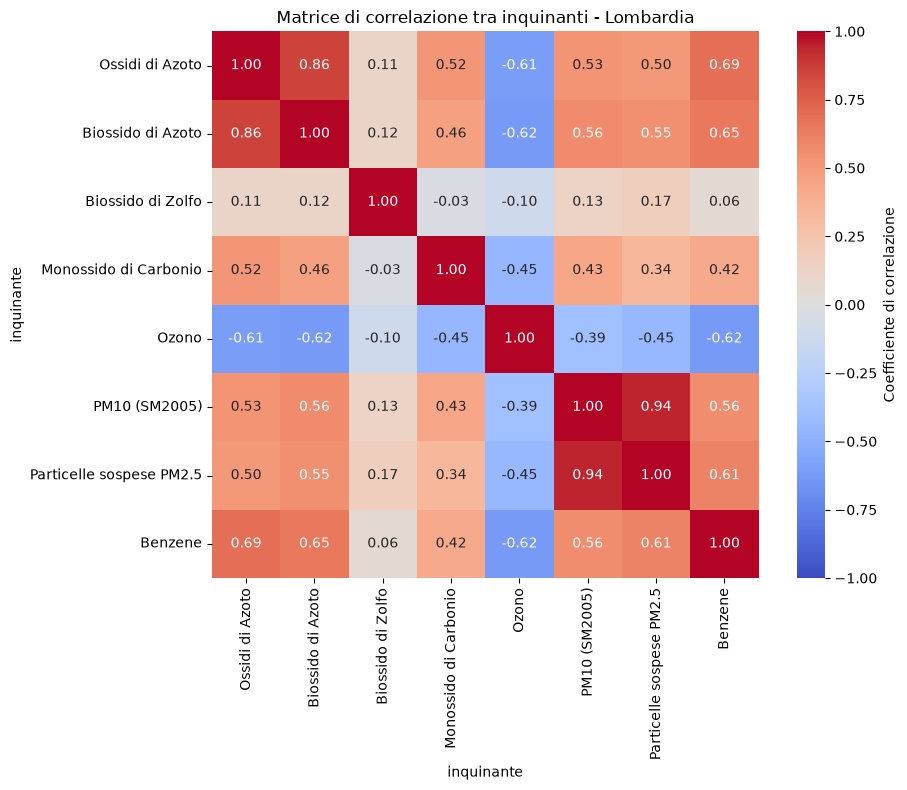

In [26]:
#heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,        # mostra i valori numerici nelle celle
            fmt='.2f',
            cmap='coolwarm',   # rosso=positiva, blu=negativa
            vmin=-1, vmax=1,
            square=True,
            cbar_kws={'label': 'Coefficiente di correlazione'})
plt.title('Matrice di correlazione tra inquinanti - Lombardia')
plt.tight_layout()
plt.savefig('correlazione_inquinanti.png', dpi=300)
plt.show()

## Pattern principali emersi: 
forte correlazione tra NOx e NO2 (0.86) e tra PM10 e PM2.5 (0.94), coerentemente con la relazione diretta tra questi inquinanti, infatti NOx è ottenuto come la somma di NO e NO2, il PM2.5 è un sottoinsieme del PM10; l'ozono è correlato negativamente con quasi tutti gli altri inquinanti (es. -0.62 con NO2 e Benzene), coerentemente con la sua dinamica fotochimica legata al traffico.

# PCA

In [28]:
df_pivot[inquinanti].notna().sum().sort_values(ascending=False)

inquinante
Biossido di Azoto           27905
Ossidi di Azoto             27544
PM10 (SM2005)               19338
Ozono                       14329
Monossido di Carbonio        8805
Particelle sospese PM2.5     8483
Biossido di Zolfo            7405
Benzene                      5630
dtype: int64

In [32]:
#selezione dei 4 inquinanti con più misurazioni
subset = ['Biossido di Azoto', 'Ossidi di Azoto', 'PM10 (SM2005)', 'Ozono']
#selezione delle stazioni con i dati completi per i 4 inquinanti
df_completo = df_pivot[subset + ['idstazione']].dropna()

In [37]:
#verifica di quante righe restano
n_totale = len(df_pivot)
n_rimaste = df_pivot[subset].dropna().shape[0]

print(f"Righe totali: {n_totale}")
print(f"Righe rimaste dopo dropna congiunto: {n_rimaste}")
print(f"Percentuale conservata: {n_rimaste / n_totale:.1%}")

Righe totali: 29313
Righe rimaste dopo dropna congiunto: 8359
Percentuale conservata: 28.5%


In [34]:
#verifica della copertura marginale dei 4 inquinanti nel subset
print(df_pivot[subset].notna().mean())

inquinante
Biossido di Azoto    0.951967
Ossidi di Azoto      0.939651
PM10 (SM2005)        0.659707
Ozono                0.488827
dtype: float64


In [38]:
#verifica di quante stazioni restano rappresentate dopo il dropna congiunto
print(f"Stazioni con dati completi: {df_completo['idstazione'].nunique()} su {df_pivot['idstazione'].nunique()}")
#verifica se le stazioni rimaste sono sparse o concentrate (varianza spaziale)
df_completo.groupby('idstazione').size().describe()

Stazioni con dati completi: 25 su 81


count     25.000000
mean     334.360000
std       21.807644
min      254.000000
25%      325.000000
50%      340.000000
75%      348.000000
max      359.000000
dtype: float64

In [ ]:
#Principal Component Analysis
X = df_completo[subset].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

print("Varianza spiegata per componente:", pca.explained_variance_ratio_)
print("Varianza cumulata:", pca.explained_variance_ratio_.cumsum())

Varianza spiegata per componente: [0.71303702 0.15922141 0.09816698 0.0295746 ]
Varianza cumulata: [0.71303702 0.87225843 0.9704254  1.        ]


Le prime 2 componenti principali spiegano circa l'87% della varianza totale

In [40]:
#cosa rappresentano le prime 2 componenti principali (PC1 e PC2)
loadings = pd.DataFrame(
    pca.components_.T,
    index=subset,
    columns=[f'PC{i+1}' for i in range(len(subset))]
)
print(loadings[['PC1', 'PC2']])

                        PC1       PC2
Biossido di Azoto  0.553943 -0.074222
Ossidi di Azoto    0.543938 -0.127898
PM10 (SM2005)      0.420619  0.842056
Ozono             -0.469423  0.518724


PC1: stesso segno per NOx e NO2, segno opposto per O3 —> inquinamento da traffico/combustione vs inquinamento fotochimico (NO reagisce con O3 riducendone la concentrazione locale);
PC2: dominata da PM10 -> dinamica legata a fattori meteo/stagionali (inversioni termiche riscaldamento)

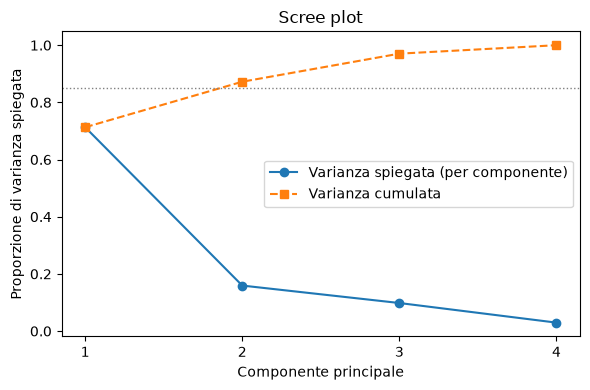

In [41]:
#scree plot
import matplotlib.pyplot as plt

n_componenti = range(1, len(pca.explained_variance_ratio_) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_componenti, pca.explained_variance_ratio_, 'o-', label='Varianza spiegata (per componente)')
ax.plot(n_componenti, pca.explained_variance_ratio_.cumsum(), 's--', label='Varianza cumulata')

ax.set_xlabel('Componente principale')
ax.set_ylabel('Proporzione di varianza spiegata')
ax.set_xticks(n_componenti)
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1)  # soglia di riferimento 85%
ax.legend()
ax.set_title('Scree plot')

plt.tight_layout()
plt.show()

Anche con l'elbow method si individuano 2 componenti principali sufficienti a spiegare più dell'80% della varianza.